1. Question: Load the Fashion MNIST datset into python using the corresponding keras library data loader. First you have to import keras and then you can load any of the pre-partitioned datsets like:

    ```(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()```

    Take a look at the data types like we have been doing with the ISLP datsets. What is the type of the loaded data here? How large is the data set and what is p here (the dimensionality of each image)?

In [6]:
# Import libraries.
import os
os.environ['KERAS_BACKEND'] = 'numpy'
import time
import warnings
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display
import keras
from keras.datasets import fashion_mnist
from sklearn import tree
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, LogisticRegression, TweedieRegressor

# Keep notebook output readable.
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Set seed.
np.random.seed(328)
pd.set_option('display.max_columns', None)

# Re-create helpers from CH8 JNB, slightly modified for multiclass use.
def accuracy(T, P, c = 0):
    a = 0
    for i in range(len(T)):
        if T[i] == c and T[i] == P[i]:
            a += 1
    n_denom = np.sum([(1 if e == c else 0) for e in T])
    m_denom = np.sum([(1 if e == c else 0) for e in P])
    n = a / n_denom if n_denom else 0.0
    m = a / m_denom if m_denom else 0.0
    return 0.0 if (n + m) == 0 else 2 * (n * m) / (n + m)

def macro_accuracy(T, P):
    classes = sorted(set(np.asarray(T).tolist()) | set(np.asarray(P).tolist()))
    return float(np.mean([accuracy(T, P, c = c) for c in classes]))

def to_labels(pred):
    return np.clip(np.rint(pred), 0, 9).astype(np.uint8)

def pixel_to_rc(idx, width = 28):
    return idx // width, idx % width

# Load Fashion MNIST.
fashion_data = fashion_mnist.load_data()
(x_train, y_train), (x_test, y_test) = fashion_data
p_image = x_train.shape[1] * x_train.shape[2]

print('keras version:', keras.__version__)
print('type(load_data output):', type(fashion_data))
print('type(training pair):', type(fashion_data[0]))
print('type(x_train):', type(x_train))
print('type(y_train):', type(y_train))
print('x_train shape / dtype:', x_train.shape, x_train.dtype)
print('y_train shape / dtype:', y_train.shape, y_train.dtype)
print('x_test shape / dtype:', x_test.shape, x_test.dtype)
print('y_test shape / dtype:', y_test.shape, y_test.dtype)
print('total images:', len(x_train) + len(x_test))
print('p (flattened pixels per image):', p_image)

keras version: 3.13.2
type(load_data output): <class 'tuple'>
type(training pair): <class 'tuple'>
type(x_train): <class 'numpy.ndarray'>
type(y_train): <class 'numpy.ndarray'>
x_train shape / dtype: (60000, 28, 28) uint8
y_train shape / dtype: (60000,) uint8
x_test shape / dtype: (10000, 28, 28) uint8
y_test shape / dtype: (10000,) uint8
total images: 70000
p (flattened pixels per image): 784


1. Answer: Using `keras.datasets.fashion_mnist.load_data()`, the returned object is a tuple of two tuples, and each of the actual data objects is a `numpy.ndarray`. In particular, `x_train` and `x_test` are `uint8` arrays with shapes `(60000, 28, 28)` and `(10000, 28, 28)`, while `y_train` and `y_test` are `uint8` arrays with shapes `(60000,)` and `(10000,)`. So the full dataset contains 70,000 grayscale images, already partitioned into 60,000 training images and 10,000 test images. Each image is a $28\times28$ grid, so in the flattened predictor sense the dimensionality is $p = 28\cdot 28 = 784$ pixels per image.

2. Question: Take a look at the built in scikit-learn tree method as shown in this example here: https://scikit-learn.org/stable/modules/tree.html. First copy the iris dataset and make sure you can repeat what in is the tutorial and build the classifier and report its accuracy using the function you are given from CH8 JNB. Try to also generate the plot of the tree using the built-in method: tree.plot_tree(Dtc). Look at this plot for the iris data and describe in your own words how your tree works.

Iris fit + predict seconds: 0.002
Iris exact test accuracy: 0.9333
Iris macro accuracy: 0.9267
Iris depth / leaves: 5 8
Iris class-wise scores: {np.str_('setosa'): 1.0, np.str_('versicolor'): 0.9231, np.str_('virginica'): 0.8571}

Top of iris tree:
|--- petal length (cm) <= 2.60
|   |--- class: 0
|--- petal length (cm) >  2.60
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 5.35
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- petal length (cm) >  5.35
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



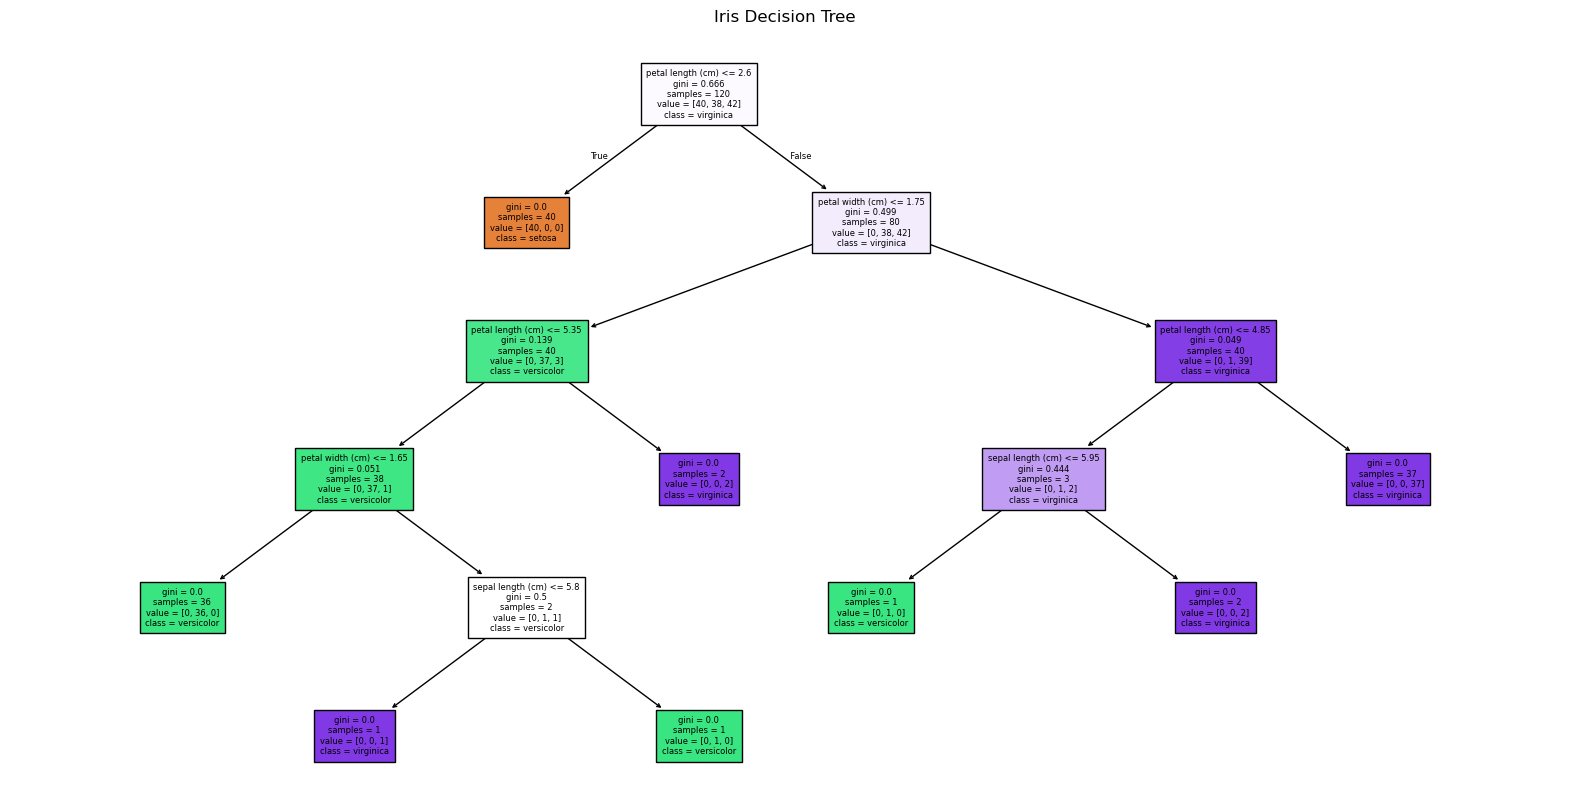

In [7]:
# Repeat the iris decision-tree example.
iris = load_iris(as_frame = True)
iris_df = iris.frame.copy()
iris_xs = iris.feature_names
iris_split = 0.2
iris_train = list(np.random.choice(range(len(iris_df)), int(len(iris_df) * (1.0 - iris_split)), replace = False))
iris_test = sorted(set(range(len(iris_df))).difference(set(iris_train)))
start = time.perf_counter()
iris_tree = tree.DecisionTreeClassifier(random_state = 328).fit(iris_df.loc[iris_train][iris_xs], iris_df.loc[iris_train]['target'])
iris_pred = iris_tree.predict(iris_df.loc[iris_test][iris_xs])
iris_seconds = time.perf_counter() - start
iris_true = np.asarray(iris_df.loc[iris_test]['target'], dtype = np.int64)
iris_exact = float(np.mean(iris_true == iris_pred))
iris_macro = macro_accuracy(iris_true, iris_pred)
iris_class_scores = {
    iris.target_names[c]: float(accuracy(iris_true, iris_pred, c = int(c)))
    for c in sorted(set(iris_true))
}
iris_top_text = tree.export_text(iris_tree, feature_names = iris_xs, max_depth = 3)
print('Iris fit + predict seconds:', round(iris_seconds, 3))
print('Iris exact test accuracy:', round(iris_exact, 4))
print('Iris macro accuracy:', round(iris_macro, 4))
print('Iris depth / leaves:', iris_tree.get_depth(), iris_tree.get_n_leaves())
print('Iris class-wise scores:', {k: round(v, 4) for k, v in iris_class_scores.items()})
print()
print('Top of iris tree:')
print(iris_top_text)
plt.figure(figsize = (20, 10))
tree.plot_tree(
    iris_tree,
    feature_names = iris_xs,
    class_names = list(iris.target_names),
    filled = True,
    fontsize = 6
)
plt.title('Iris Decision Tree')
plt.show()

2. Answer: Using an 80/20 random partition, the iris decision tree achieved exact test accuracy $0.9333$. Using the class-wise accuracy helper and then averaging over the three species, the macro score was $0.9267$. The class-wise scores were `setosa = 1.0000`, `versicolor = 0.9231`, and `virginica = 0.8571`, and the fitted tree had depth `5` with `8` leaves. From the plot and the exported text, the tree first splits on `petal length (cm) <= 2.60`, which cleanly isolates `setosa`. After that it mainly uses `petal width` and `petal length` again to separate `versicolor` from `virginica`. So the tree works by asking a sequence of threshold questions on flower measurements until each terminal region is mostly one species.

3. Question: Now adapt your code from Question 2 to work on the harder Fashion MNIST dataset you loaded in Question 1. You will get an error since your new dataset is 3D in structure. This is because your X variables here are no longer a column vector. Y ou can alter that by flattening the dimension for each image using something like this:

    ```xs_train = np.asarray([x.flatten() for x in x_train],dtype=np.uint8)```
    
    Be sure to use this new transformed version of your X instead of x_train. Y ou are making a basic decision tree (tree.DecisionTreeClassifier()) on image data and then calculating accuracy on it using the not-seen test data set. Plot your tree again and see if you can describe how it works.

xs_train shape: (60000, 784) uint8
xs_test shape: (10000, 784) uint8
Fashion tree fit + predict seconds: 21.547
Fashion tree exact test accuracy: 0.7894
Fashion tree macro accuracy: 0.7896
Fashion tree depth / leaves: 49 4903
Root split pixel: 207 -> row/col (7, 11) threshold 7.5
Next left-branch pixel: 599 -> row/col (21, 11)
Next right-branch pixel: 546 -> row/col (19, 14)
Fashion tree class-wise scores: {0: 0.7368, 1: 0.9502, 2: 0.6448, 3: 0.7992, 4: 0.6371, 5: 0.9042, 6: 0.5318, 7: 0.8822, 8: 0.9035, 9: 0.9063}

Top of Fashion MNIST tree:
|--- px_207 <= 7.50
|   |--- px_599 <= 82.50
|   |   |--- px_405 <= 12.50
|   |   |   |--- px_394 <= 9.50
|   |   |   |   |--- truncated branch of depth 13
|   |   |   |--- px_394 >  9.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- px_405 >  12.50
|   |   |   |--- px_390 <= 13.50
|   |   |   |   |--- truncated branch of depth 18
|   |   |   |--- px_390 >  13.50
|   |   |   |   |--- truncated branch of depth 32
|   |--- px_599 >  

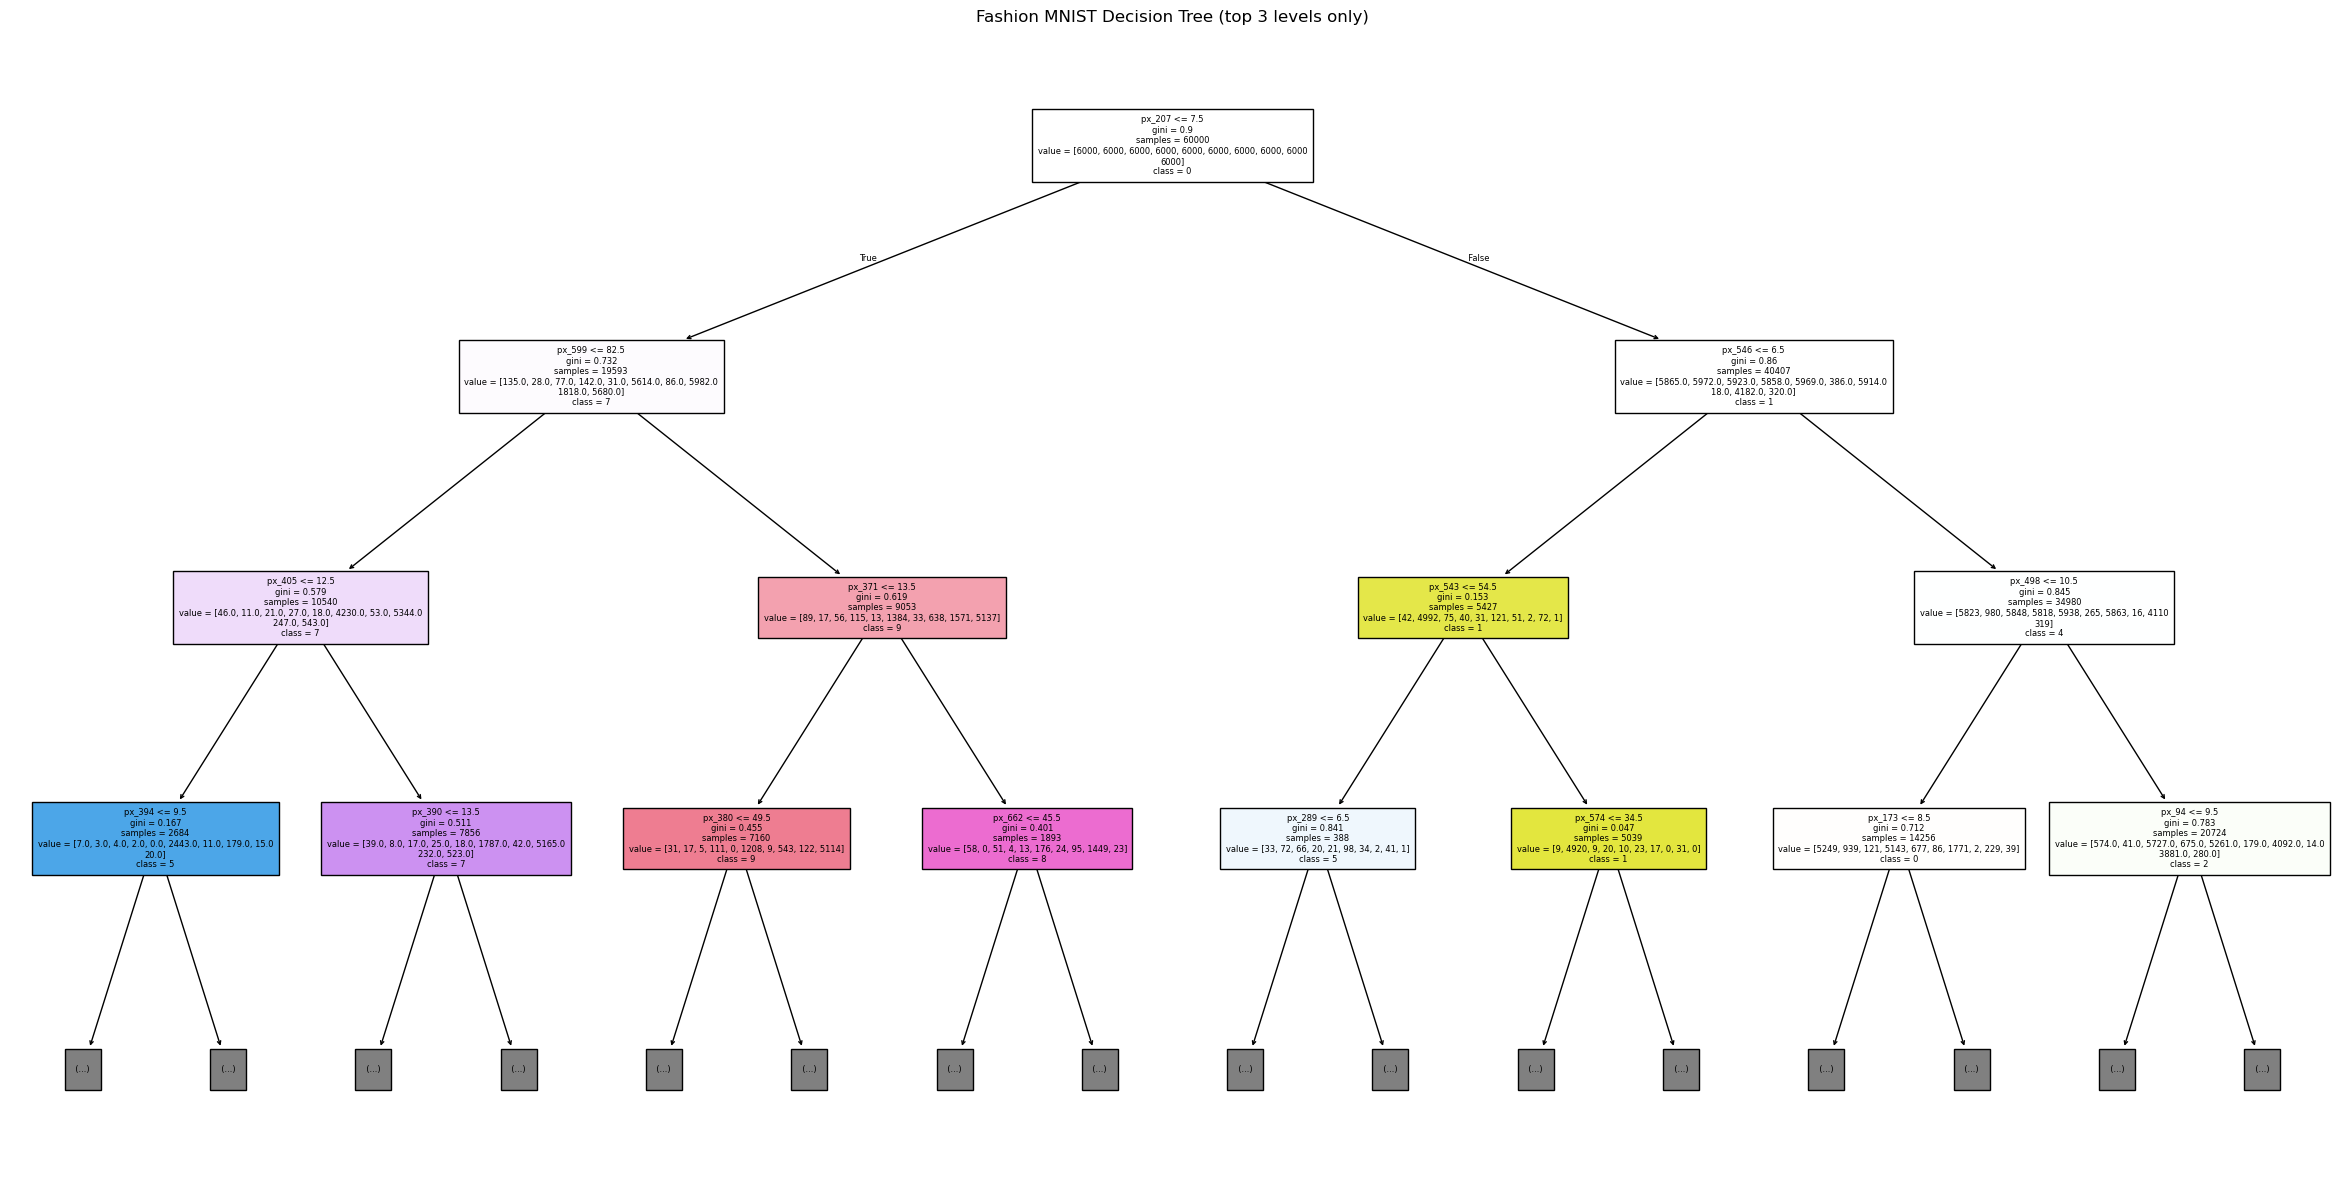

In [8]:
# Flatten the Fashion MNIST images so each image becomes a length-784 predictor vector.
xs_train = np.asarray([x.flatten() for x in x_train], dtype = np.uint8)
xs_test = np.asarray([x.flatten() for x in x_test], dtype = np.uint8)
fashion_pixel_names = [f'px_{i}' for i in range(xs_train.shape[1])]

# Now, repeat decision tree fitting.
start = time.perf_counter()
fashion_tree = tree.DecisionTreeClassifier(random_state = 328).fit(xs_train, y_train)
fashion_tree_pred = fashion_tree.predict(xs_test)
fashion_tree_seconds = time.perf_counter() - start
fashion_tree_exact = float(np.mean(y_test == fashion_tree_pred))
fashion_tree_macro = macro_accuracy(y_test, fashion_tree_pred)
fashion_tree_class_scores = {
    int(c): float(accuracy(y_test, fashion_tree_pred, c = int(c)))
    for c in sorted(set(y_test))
}
fashion_tree_root = int(fashion_tree.tree_.feature[0])
fashion_tree_root_threshold = float(fashion_tree.tree_.threshold[0])
fashion_tree_left = int(fashion_tree.tree_.children_left[0])
fashion_tree_right = int(fashion_tree.tree_.children_right[0])
fashion_tree_left_feature = int(fashion_tree.tree_.feature[fashion_tree_left])
fashion_tree_right_feature = int(fashion_tree.tree_.feature[fashion_tree_right])
fashion_tree_top_text = tree.export_text(fashion_tree, feature_names = fashion_pixel_names, max_depth = 3)
print('xs_train shape:', xs_train.shape, xs_train.dtype)
print('xs_test shape:', xs_test.shape, xs_test.dtype)
print('Fashion tree fit + predict seconds:', round(fashion_tree_seconds, 3))
print('Fashion tree exact test accuracy:', round(fashion_tree_exact, 4))
print('Fashion tree macro accuracy:', round(fashion_tree_macro, 4))
print('Fashion tree depth / leaves:', fashion_tree.get_depth(), fashion_tree.get_n_leaves())
print('Root split pixel:', fashion_tree_root, '-> row/col', pixel_to_rc(fashion_tree_root), 'threshold', round(fashion_tree_root_threshold, 2))
print('Next left-branch pixel:', fashion_tree_left_feature, '-> row/col', pixel_to_rc(fashion_tree_left_feature))
print('Next right-branch pixel:', fashion_tree_right_feature, '-> row/col', pixel_to_rc(fashion_tree_right_feature))
print('Fashion tree class-wise scores:', {k: round(v, 4) for k, v in fashion_tree_class_scores.items()})
print()
print('Top of Fashion MNIST tree:')
print(fashion_tree_top_text)

# The full tree is enormous, so show the top levels only.
plt.figure(figsize = (30, 15))
tree.plot_tree(
    fashion_tree,
    max_depth = 3,
    feature_names = fashion_pixel_names,
    class_names = [str(i) for i in range(10)],
    filled = True,
    fontsize = 6
)
plt.title('Fashion MNIST Decision Tree (top 3 levels only)')
plt.show()

3. Answer: After flattening the images, `xs_train` had shape `(60000, 784)` and `xs_test` had shape `(10000, 784)`, so each image became a 784-dimensional predictor vector. The basic decision tree reached exact test accuracy $0.7894$, and the macro accuracy was $0.7896$. The fitted tree was much larger than the iris tree, with depth `49` and `4903` leaves. Its strongest class-wise scores were for labels `1`, `5`, `8`, and `9` (about `0.9502`, `0.9042`, `0.9035`, and `0.9063`, respectively), while one of the weakest was label `6` at about `0.5318`. The top of the tree shows that it works by thresholding individual pixels: the root split is `px_207 <= 7.5` (pixel `(7, 11)` in the $28\times28$ image), and the next main tests involve pixels such as `px_599`, `px_405`, and `px_546`. In other words, the model classifies clothing by asking many yes/no questions about whether specific image locations are dark or bright, so it is partitioning the image space into many rectangular pixel-intensity regions.

4. Question: Now repeat the same process in Question 3 but use the RandomForest classifier as show in CH8 JNB instead with that same flattened version of x_train called xs_train. Compare the overall accuracy between the tree models and explain which one performs better and why you think that is the case.

In [9]:
# Compare random forests with different numbers of trees.
forest_rows = []
best_forest_model = None
best_forest_pred = None
best_forest_exact = -1.0
best_forest_macro = -1.0
best_forest_n = None
for n_estimators in [1, 10, 25, 50, 100]:
    start = time.perf_counter()
    forest_model = RandomForestClassifier(n_estimators = n_estimators, random_state = 328, n_jobs = -1).fit(xs_train, y_train)
    forest_pred = forest_model.predict(xs_test)
    forest_seconds = time.perf_counter() - start
    forest_exact = float(np.mean(y_test == forest_pred))
    forest_macro = macro_accuracy(y_test, forest_pred)
    forest_rows.append({
        'n_estimators': n_estimators,
        'fit_seconds': forest_seconds,
        'exact_accuracy': forest_exact,
        'macro_accuracy': forest_macro
    })
    if forest_exact > best_forest_exact:
        best_forest_model = forest_model
        best_forest_pred = forest_pred
        best_forest_exact = forest_exact
        best_forest_macro = forest_macro
        best_forest_n = n_estimators
forest_results = pd.DataFrame(forest_rows)
display(forest_results.round(4))
best_forest_class_scores = {
    int(c): float(accuracy(y_test, best_forest_pred, c = int(c)))
    for c in sorted(set(y_test))
}
print('Best forest n_estimators:', best_forest_n)
print('Best forest exact test accuracy:', round(best_forest_exact, 4))
print('Best forest macro accuracy:', round(best_forest_macro, 4))
print('Best forest class-wise scores:', {k: round(v, 4) for k, v in best_forest_class_scores.items()})

,n_estimators,fit_seconds,exact_accuracy,macro_accuracy
0,1,0.4899,0.7642,0.7643
1,10,0.6568,0.8500,0.8483
2,25,1.7073,0.8651,0.8636
3,50,2.9864,0.8721,0.8708
4,100,5.5721,0.8768,0.8755


Best forest n_estimators: 100
Best forest exact test accuracy: 0.8768
Best forest macro accuracy: 0.8755
Best forest class-wise scores: {0: 0.8392, 1: 0.9776, 2: 0.7809, 3: 0.8909, 4: 0.7932, 5: 0.9673, 6: 0.6471, 7: 0.9391, 8: 0.9688, 9: 0.9513}


4. Answer: The random forest outperformed the single decision tree, and the improvement was consistent as I increased the number of trees. The exact test accuracies were `0.7642` for `n_estimators=1`, `0.8500` for `10`, `0.8651` for `25`, `0.8721` for `50`, and `0.8768` for `100`. The best forest here was therefore `RandomForestClassifier(n_estimators=100)`, which also had macro accuracy `0.8755`. That is clearly better than the single decision tree from Question 3 (`0.7894` exact, `0.7896` macro). This makes sense because a single tree has high variance and can overfit sharp pixel-threshold rules, while the random forest averages many decorrelated trees and therefore stabilizes the decision boundaries.

5. Question: Build your best linear model (Tweedie regressor will work best since image data values a [0,255]) and compare this best linear model to your best tree method.

In [10]:
# Compare several linear-model choices against the same image predictors.
xs_train_float = xs_train.astype(np.float32)
xs_test_float = xs_test.astype(np.float32)
linear_rows = []
linear_preds = {}
start = time.perf_counter()
lin_model = LinearRegression().fit(xs_train_float, y_train)
lin_pred = to_labels(lin_model.predict(xs_test_float))
linear_rows.append({
    'model': 'LinearRegression + rounded labels',
    'fit_seconds': time.perf_counter() - start,
    'exact_accuracy': float(np.mean(y_test == lin_pred)),
    'macro_accuracy': macro_accuracy(y_test, lin_pred)
})
linear_preds['LinearRegression + rounded labels'] = lin_pred

start = time.perf_counter()
tweedie_p1 = TweedieRegressor(power = 1, alpha = 0.5, max_iter = 300).fit(xs_train_float, y_train)
tweedie_p1_pred = to_labels(tweedie_p1.predict(xs_test_float))
linear_rows.append({
    'model': 'TweedieRegressor(power=1, alpha=0.5)',
    'fit_seconds': time.perf_counter() - start,
    'exact_accuracy': float(np.mean(y_test == tweedie_p1_pred)),
    'macro_accuracy': macro_accuracy(y_test, tweedie_p1_pred)
})
linear_preds['TweedieRegressor(power=1, alpha=0.5)'] = tweedie_p1_pred

start = time.perf_counter()
tweedie_p0 = TweedieRegressor(power = 0, alpha = 0.5, max_iter = 300).fit(xs_train_float, y_train)
tweedie_p0_pred = to_labels(tweedie_p0.predict(xs_test_float))
linear_rows.append({
    'model': 'TweedieRegressor(power=0, alpha=0.5)',
    'fit_seconds': time.perf_counter() - start,
    'exact_accuracy': float(np.mean(y_test == tweedie_p0_pred)),
    'macro_accuracy': macro_accuracy(y_test, tweedie_p0_pred)
})
linear_preds['TweedieRegressor(power=0, alpha=0.5)'] = tweedie_p0_pred

start = time.perf_counter()
log_model = LogisticRegression(C = 1.0, solver = 'lbfgs', max_iter = 300).fit(xs_train_float, y_train)
log_pred = log_model.predict(xs_test_float)
linear_rows.append({
    'model': 'LogisticRegression(C=1.0, solver="lbfgs")',
    'fit_seconds': time.perf_counter() - start,
    'exact_accuracy': float(np.mean(y_test == log_pred)),
    'macro_accuracy': macro_accuracy(y_test, log_pred)
})
linear_preds['LogisticRegression(C=1.0, solver="lbfgs")'] = log_pred
linear_results = pd.DataFrame(linear_rows).sort_values('exact_accuracy', ascending = False).reset_index(drop = True)
display(linear_results.round(4))
best_linear_name = linear_results.loc[0, 'model']
best_linear_pred = linear_preds[best_linear_name]
best_linear_exact = float(linear_results.loc[0, 'exact_accuracy'])
best_linear_macro = float(linear_results.loc[0, 'macro_accuracy'])
best_linear_class_scores = {
    int(c): float(accuracy(y_test, best_linear_pred, c = int(c)))
    for c in sorted(set(y_test))
}
comparison_results = pd.DataFrame([
    {
        'model': best_linear_name,
        'exact_accuracy': best_linear_exact,
        'macro_accuracy': best_linear_macro
    },
    {
        'model': f'RandomForestClassifier(n_estimators={best_forest_n})',
        'exact_accuracy': best_forest_exact,
        'macro_accuracy': best_forest_macro
    }
])
display(comparison_results.round(4))
print('Best linear model class-wise scores:', {k: round(v, 4) for k, v in best_linear_class_scores.items()})

,model,fit_seconds,exact_accuracy,macro_accuracy
0,"LogisticRegression(C=1.0, solver=""lbfgs"")",11.6789,0.8392,0.8382
1,LinearRegression + rounded labels,1.0158,0.3855,0.3858
2,"TweedieRegressor(power=0, alpha=0.5)",44.9849,0.3782,0.3794
3,"TweedieRegressor(power=1, alpha=0.5)",0.4259,0.1000,0.0182


,model,exact_accuracy,macro_accuracy
0,"LogisticRegression(C=1.0, solver=""lbfgs"")",0.8392,0.8382
1,RandomForestClassifier(n_estimators=100),0.8768,0.8755


Best linear model class-wise scores: {0: 0.7948, 1: 0.9604, 2: 0.7329, 3: 0.8375, 4: 0.746, 5: 0.9211, 6: 0.5914, 7: 0.9212, 8: 0.9372, 9: 0.9401}


5. Answer: I compared several linear-family models on the same flattened image predictors. The measured exact test accuracies were `0.3855` for `LinearRegression` after rounding/clipping to labels `0`-`9`, `0.1000` for `TweedieRegressor(power=1, alpha=0.5)`, `0.3782` for `TweedieRegressor(power=0, alpha=0.5)`, and `0.8392` for `LogisticRegression(C=1.0, solver="lbfgs", max_iter=300)`. The corresponding CH8 macro accuracies were `0.3858`, `0.0182`, `0.3794`, and `0.8382`. So the best linear model from the class toolkit was logistic regression, not Tweedie. That is also the most appropriate linear choice here, because the response is a 10-class qualitative label rather than a count response. Compared with the best tree method, `RandomForestClassifier(n_estimators=100)` still performed better: its exact test accuracy was `0.8768` and its macro accuracy was `0.8755`, which is about `0.0376` higher in exact accuracy than the best linear model. So a linear decision boundary over the 784 pixels works reasonably well, but the random forest captures more nonlinear/local pixel interactions than the linear model can.